In [1]:
import os
from pathlib import Path
import pandas as pd
import shapely
import geopandas as gpd
import matplotlib.pyplot as plt

# === Setup ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import xarray as xr

In [2]:
data_path_risk = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\MIRACA\MIRACA_results")
# Get all results
risk_files = list(data_path_risk.glob('*.parquet')) + list(data_path_risk.glob('*.csv'))

In [3]:
COUNTRIES = ['SVN', 'SVK', 'AUT', 'BEL', 'BGR', 'CHE', 'CYP', 
             'CZE', 'DEU', 'DNK', 'EST', 'GRC', 'ESP', 'FIN', 'FRA', 'HRV', 
             'HUN', 'IRL', 'ISL', 'ITA', 'LIE', 'LTU', 'LUX', 'LVA',  
             'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SWE']


In [4]:
INFRASTRUCTURE_TYPES = [
    "healthcare",
    "education",
    "power",
    "rail",
    "roads",
    "telecom",
]

In [5]:
# power_fix = {
#     'ESP' : 55077525.60505185,
#     'HUN' : 27668092.456383612,
#     'IRL' : 353135089.8360846,
#     'NOR' : 46217927.029630184,
#     'SWE' : 29729656.43432185,
#     'LTU' : 6261944.281232944    
# }

In [6]:
# === Data Loading ===
import geopandas as gpd
from shapely import wkt

risk_data = {}

for file_path in risk_files:
    filename = file_path.name if hasattr(file_path, 'name') else str(file_path).split('/')[-1]
    
    # Parse filename - works for both parquet and csv
    pattern = r"([A-Z]{3})_([a-z_]+)_(.+)_risk\.(parquet|csv)"
    match = re.match(pattern, filename)
    
    if not match:
        continue
        
    country, system, hazard_full, file_type = match.groups()
    
    # Simplify hazard names
    if 'coastal' in hazard_full:
        hazard = 'coastal'
    elif 'river' in hazard_full:
        hazard = 'fluvial'
    elif 'earthquake' in hazard_full:
        hazard = 'earthquake'
    elif 'windstorm' in hazard_full:
        hazard = 'windstorms'
    else:
        continue
    
    # Load based on file type
    if file_type == 'parquet':
        df = pd.read_parquet(file_path)
    else:  # csv
        df = pd.read_csv(file_path)
        # Convert WKT geometry to proper geopandas geometry
        # if 'geometry' in df.columns:
        #     df['geometry'] = df['geometry'].apply(wkt.loads)
        #     df = gpd.GeoDataFrame(df)
    

    # Filter out plants for power windstorm files
    if system == 'power' and hazard == 'windstorms':
        object_types = ['line', 'tower', 'catenary_mast', 'pole', 'minor_line']

        df = df[df['object_type'].isin(
            object_types
        )]
        
        for obj_type in object_types:
            mask = df['object_type'] == obj_type
            if mask.any():
                ead_95th = df.loc[mask, 'EAD'].quantile(0.75)
                df.loc[mask, 'EAD'] = df.loc[mask, 'EAD'].clip(upper=ead_95th)
        # try:
        #     df = df.loc[df.geometry.geom_type != 'MultiPolygon']

    
    # # Sum the EAD values
    # if system == 'power' and hazard == 'windstorms':
    #     if country in list(power_fix.keys()):
    #         total_ead = power_fix[country] 
    # else:
    total_ead = df['EAD'].sum()
    
    # Store in nested dict
    if country not in risk_data:
        risk_data[country] = {}
    if system not in risk_data[country]:
        risk_data[country][system] = {}
    risk_data[country][system][hazard] = total_ead


In [7]:
# === Data Processing ===
# Create summary dataframes by infrastructure type
infra_summaries = {}

for infra in INFRASTRUCTURE_TYPES:
    # Create dataframe: countries as rows, hazards as columns
    hazard_list = list(set([h for country_data in risk_data.values() 
                           for infra_data in country_data.values() 
                           for h in infra_data.keys()]))
    
    df = pd.DataFrame(index=COUNTRIES, columns=hazard_list, dtype=float)
    df = df.fillna(0)
    
    for country in COUNTRIES:
        if country in risk_data and infra in risk_data[country]:
            for hazard, ead in risk_data[country][infra].items():
                df.loc[country, hazard] = ead
    
    infra_summaries[infra] = df

# Get top countries overall (across all infrastructure)
total_ead_by_country = pd.Series(index=COUNTRIES, dtype=float)
for country in COUNTRIES:
    total = 0
    for infra in INFRASTRUCTURE_TYPES:
        total += infra_summaries[infra].loc[country].sum()
    total_ead_by_country[country] = total

top_countries_overall = total_ead_by_country.sort_values(ascending=False).index

# Get common hazards across all infrastructure types
all_hazards = set()
for infra in INFRASTRUCTURE_TYPES:
    all_hazards.update(infra_summaries[infra].columns)
common_hazards = list(all_hazards)

In [9]:
# Color and label definitions
hazard_colors = {
   "fluvial": "#8ecae6",
   "coastal": "#219ebc",  
   "earthquake": "#fb8500",
   "windstorms": "#023047"
}

legend_labels = {
   "fluvial": "Fluvial",
   "coastal": "Coastal",
   "earthquake": "Earthquake",
   "windstorms": "Windstorms"
}


In [27]:
# === Get countries with data and sort by EAD value (descending) ===
countries_with_data = [country for country in total_ead_by_country.index 
                  if total_ead_by_country[country] > 0]

# Sort ALL countries by their total EAD value first (highest to lowest)
countries_by_ead = sorted(countries_with_data, 
                     key=lambda x: total_ead_by_country[x], 
                     reverse=True)  # Highest EAD first

# === Split the SORTED list into two halves ===
mid_point = len(countries_by_ead) // 2
countries_first_half = countries_by_ead[mid_point:]  # Highest EAD countries
countries_second_half = countries_by_ead[:mid_point]  # Lower EAD countries

# Create and save both plots with updated titles
highest_ead_country = countries_by_ead[0]
lowest_ead_country = countries_by_ead[-1]

In [35]:
countries_subset = countries_first_half

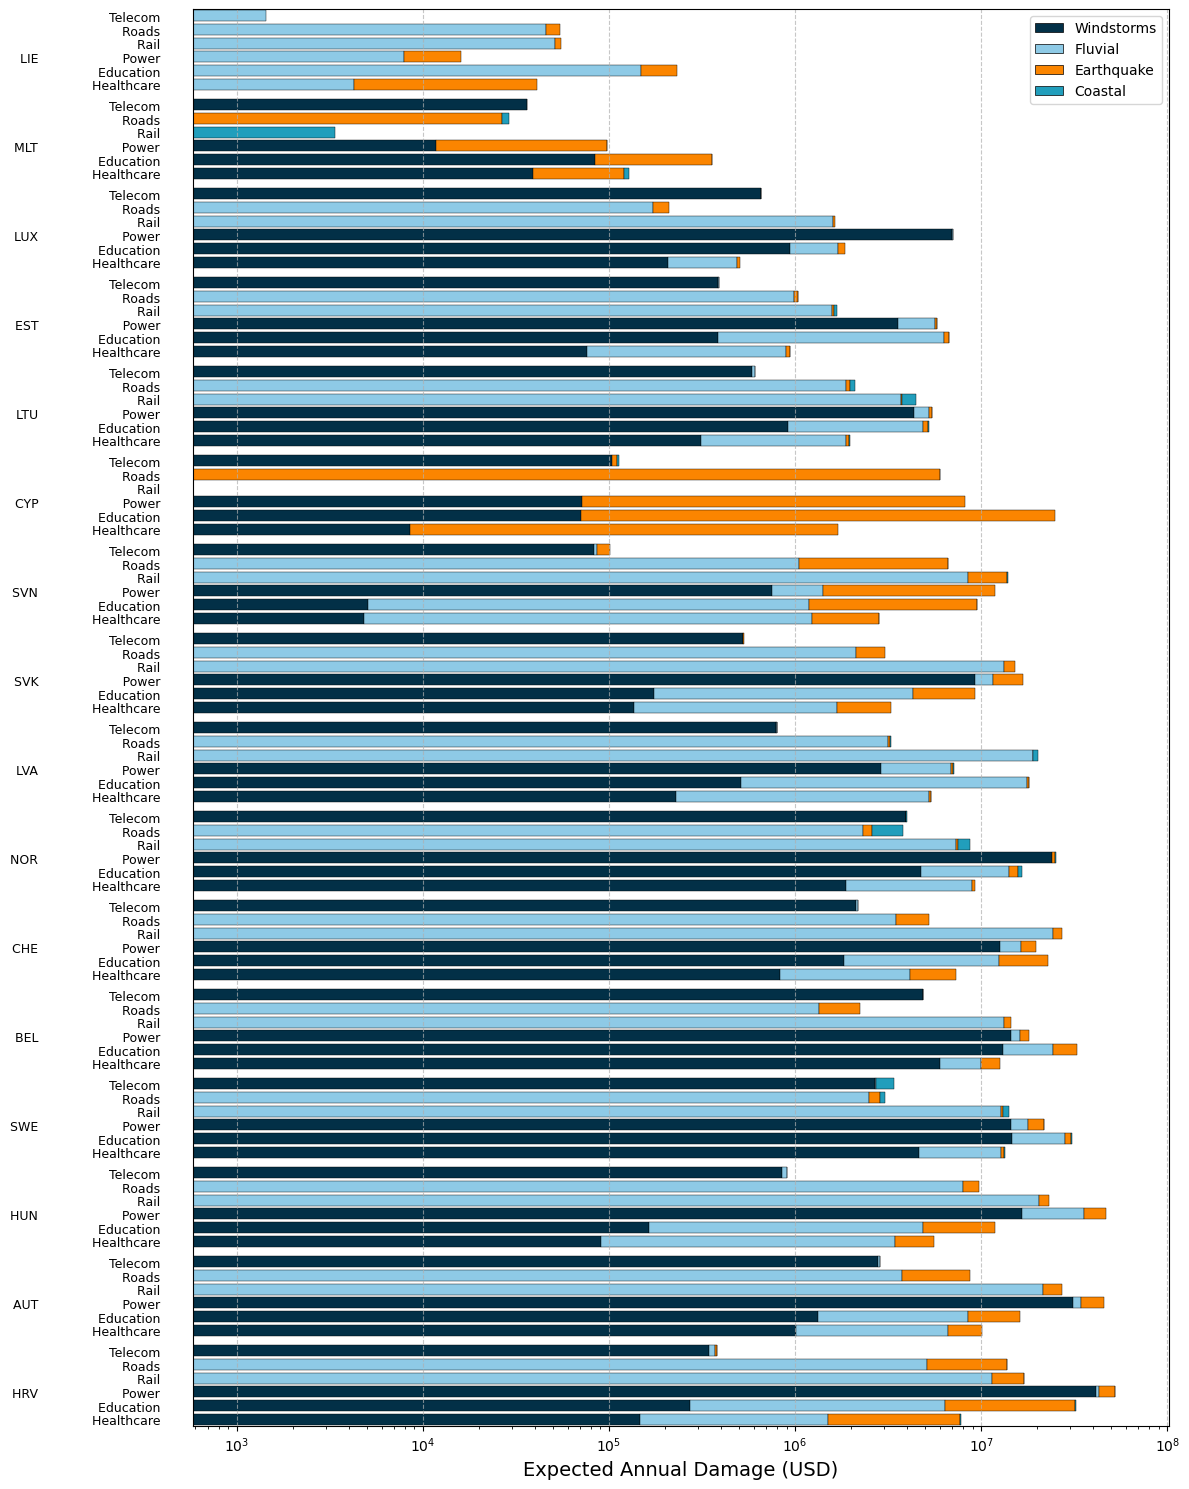

In [36]:
fig = plt.figure(constrained_layout=False, figsize=(12, 15))
f_ax2 = fig.add_subplot(111)

# === Sort the subset by EAD value (descending) for proper display ===
countries_subset_sorted = sorted(countries_subset, 
                               key=lambda x: total_ead_by_country[x], 
                               reverse=True)  # Keep highest EAD first for display

# === Stacked horizontal bars (all 5 infrastructure types) ===
n_countries = len(countries_subset_sorted)
n_infra = len(INFRASTRUCTURE_TYPES)

# Create y-positions and labels for each country-infrastructure combination
y_positions = []
y_labels = []
y_pos = 0

for country in countries_subset_sorted:  # Now starts with highest EAD
    for i, infra in enumerate(INFRASTRUCTURE_TYPES):
        y_positions.append(y_pos)
        
        # Only show country name for the middle infrastructure (power)
        if infra == "power":
            y_labels.append(f"{country}                     {infra.title()}")
        else:
            y_labels.append(f"          {infra.title()}")
        
        y_pos += 1
    y_pos += 0.5  # Add small gap between countries

bar_height = 0.8

# Plot bars for each country-infrastructure combination
y_idx = 0
for country in countries_subset_sorted:  # Same order as labels
    for infra in INFRASTRUCTURE_TYPES:
        bottom = 0
        for hazard in common_hazards:
            if hazard in infra_summaries[infra].columns:
                value = infra_summaries[infra].loc[country, hazard]
            else:
                value = 0
                
            if value > 0:
                f_ax2.barh(
                    y_positions[y_idx], value, left=bottom, height=bar_height,
                    color=hazard_colors.get(hazard, '#999999'),
                    edgecolor='black', linewidth=0.3
                )
                bottom += value
        y_idx += 1

# === Labels and customization ===
f_ax2.set_yticks(y_positions)
f_ax2.set_yticklabels(y_labels, fontsize=9)
f_ax2.set_xscale('log')
f_ax2.set_xlabel("Expected Annual Damage (USD)", fontsize=14)
#f_ax2.set_title(f"Infrastructure Risk by Country {title_suffix}", fontsize=16, pad=20)
f_ax2.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
f_ax2.tick_params(axis='y', which='both', left=False, right=False, pad=20)
f_ax2.grid(axis='x', linestyle='--', alpha=0.7)
f_ax2.invert_yaxis()  # This makes the first item appear at top

# Remove spacing at top and bottom of y-axis
f_ax2.set_ylim(-0.5, max(y_positions) + 0.5)

# === Legend ===
hazard_handles = [
    mpatches.Patch(
        facecolor=hazard_colors[haz],
        label=legend_labels[haz],
        edgecolor='black',
        linewidth=0.5
    )
    for haz in common_hazards if haz in hazard_colors
]

f_ax2.legend(
    handles=hazard_handles,
    loc="upper right",
    frameon=True
)

plt.tight_layout()

# === Save high resolution figure ===
# if save_filename:
plt.savefig('lower_ead.png', dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')
#     print(f"Saved high-res figure: {save_filename}")

Saved high-res pie charts: infrastructure_risk_distribution_pies.png


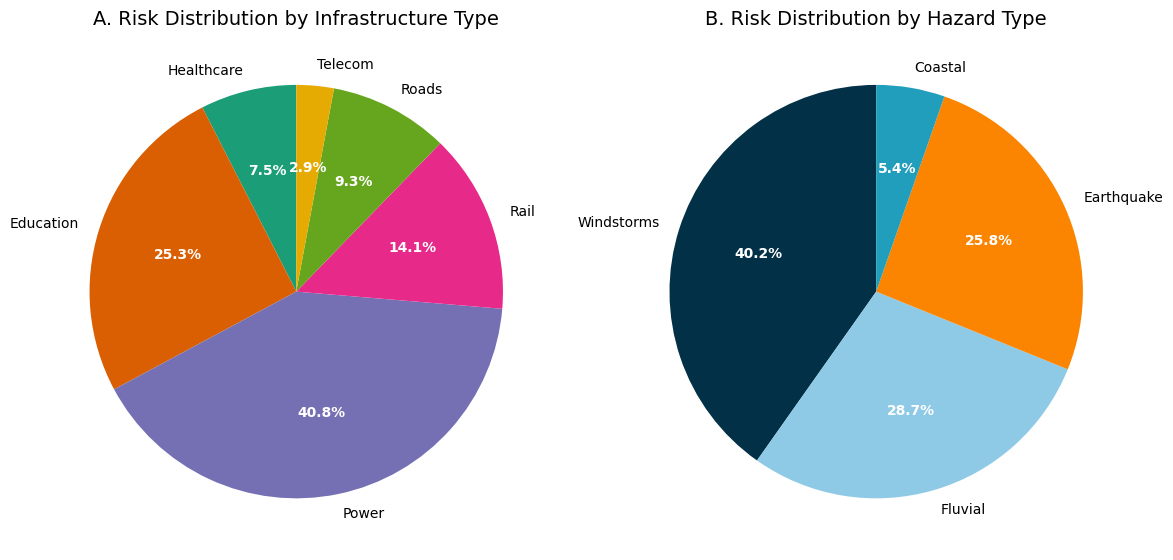


=== SUMMARY STATISTICS ===

Risk by Infrastructure Type:
Power: $2,707,962,963 (40.8%)
Education: $1,679,910,767 (25.3%)
Rail: $932,258,434 (14.1%)
Roads: $619,440,743 (9.3%)
Healthcare: $497,870,435 (7.5%)
Telecom: $193,929,131 (2.9%)

Total Infrastructure Risk: $6,631,372,472

Risk by Hazard Type:
Windstorms: $2,666,879,447 (40.2%)
Fluvial: $1,899,999,114 (28.7%)
Earthquake: $1,709,653,716 (25.8%)
Coastal: $354,840,196 (5.4%)

Total Hazard Risk: $6,631,372,472


In [18]:
# === Calculate totals for pie charts ===

# 1. Total risk by infrastructure type (across all countries and hazards)
infra_totals = {}
for infra in INFRASTRUCTURE_TYPES:
    total = infra_summaries[infra].sum().sum()  # Sum all values in the dataframe
    infra_totals[infra] = total

# 2. Total risk by hazard type (across all countries and infrastructure)
hazard_totals = {}
for hazard in common_hazards:
    total = 0
    for infra in INFRASTRUCTURE_TYPES:
        if hazard in infra_summaries[infra].columns:
            total += infra_summaries[infra][hazard].sum()
    hazard_totals[hazard] = total

# === Create side-by-side pie charts ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# === Left pie chart: Risk by Infrastructure Type ===
infra_labels = [infra.title() for infra in infra_totals.keys()]
infra_values = list(infra_totals.values())
infra_colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02']  # Different colors for each infra

wedges1, texts1, autotexts1 = ax1.pie(infra_values, labels=infra_labels, autopct='%1.1f%%', 
                                       colors=infra_colors, startangle=90)
ax1.set_title('A. Risk Distribution by Infrastructure Type', fontsize=14)#, fontweight='bold')

# Improve text formatting
for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# === Right pie chart: Risk by Hazard Type ===
hazard_labels = [legend_labels.get(hazard, hazard.title()) for hazard in hazard_totals.keys()]
hazard_values = list(hazard_totals.values())
hazard_colors_list = [hazard_colors.get(hazard, '#999999') for hazard in hazard_totals.keys()]

wedges2, texts2, autotexts2 = ax2.pie(hazard_values, labels=hazard_labels, autopct='%1.1f%%',
                                       colors=hazard_colors_list, startangle=90)
ax2.set_title('B. Risk Distribution by Hazard Type', fontsize=14)#, fontweight='bold')

# Improve text formatting
for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# === Overall formatting ===
#plt.suptitle('Global Infrastructure Risk Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# === Save high resolution ===
plt.savefig('infrastructure_risk_distribution_pies.png', dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')
print("Saved high-res pie charts: infrastructure_risk_distribution_pies.png")

plt.show()

# === Print summary statistics ===
print("\n=== SUMMARY STATISTICS ===")
print("\nRisk by Infrastructure Type:")
total_infra_risk = sum(infra_totals.values())
for infra, value in sorted(infra_totals.items(), key=lambda x: x[1], reverse=True):
    percentage = (value / total_infra_risk) * 100
    print(f"{infra.title()}: ${value:,.0f} ({percentage:.1f}%)")

print(f"\nTotal Infrastructure Risk: ${total_infra_risk:,.0f}")

print("\nRisk by Hazard Type:")
total_hazard_risk = sum(hazard_totals.values())
for hazard, value in sorted(hazard_totals.items(), key=lambda x: x[1], reverse=True):
    percentage = (value / total_hazard_risk) * 100
    hazard_name = legend_labels.get(hazard, hazard.title())
    print(f"{hazard_name}: ${value:,.0f} ({percentage:.1f}%)")

print(f"\nTotal Hazard Risk: ${total_hazard_risk:,.0f}")